# LINEARITY ANALYSIS

In [1]:
from src.system_discovery import SystemDiscovery, DiscoverNetwork
import src.constants as cn
from src.biomodels_iterator import BiomodelsIterator
from src.timecourse import Timecourse
from src.model import Model

import collections
import os
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import sbmlnetwork as sb
import tellurium as te

## Biomodels 8

In [2]:
model = Model.makeBiomodel(model_num=8)
timecourse = Timecourse(model)
timecourse.timecourse_df

,C,X,M,Y,Z
time,,,,,
0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,1.000000
0.000030,0.000005,5.052153e-16,1.589474e-10,1.000006,0.999998
0.000060,0.000009,3.875631e-15,6.348427e-10,1.000012,0.999997
0.000090,0.000014,1.328061e-14,1.427854e-09,1.000018,0.999995
0.000120,0.000019,2.976943e-14,2.537974e-09,1.000024,0.999993
...,...,...,...,...,...
0.002881,0.000446,3.496699e-10,1.456751e-06,1.000582,0.999836
0.002911,0.000451,3.606916e-10,1.487204e-06,1.000588,0.999834
0.002941,0.000456,3.719431e-10,1.517971e-06,1.000594,0.999832



  Discovered Chemical Rate Equations
(C)' =  10.562 C + -0.001 M + -8.264 Y +  2.388 Z
(X)' =  0.000
(M)' = -200372.943 C +  6.654 M +  156777.016 Y + -44233.092 Z
(Y)' =  11.182 C + -0.001 M + -8.757 Y +  2.528 Z
(Z)' = -24.874 C +  0.001 M +  19.506 Y + -5.560 Z

R² on time derivatives per species:
  C: 0.997426
  X: 0.432260
  M: 0.981771
  Y: 0.997786
  Z: 0.996873

R² on simulated trajectories per species:
  C: 1.000000
  X: -14718173450037324.000000
  M: 0.977067
  Y: 1.000000
  Z: 1.000000



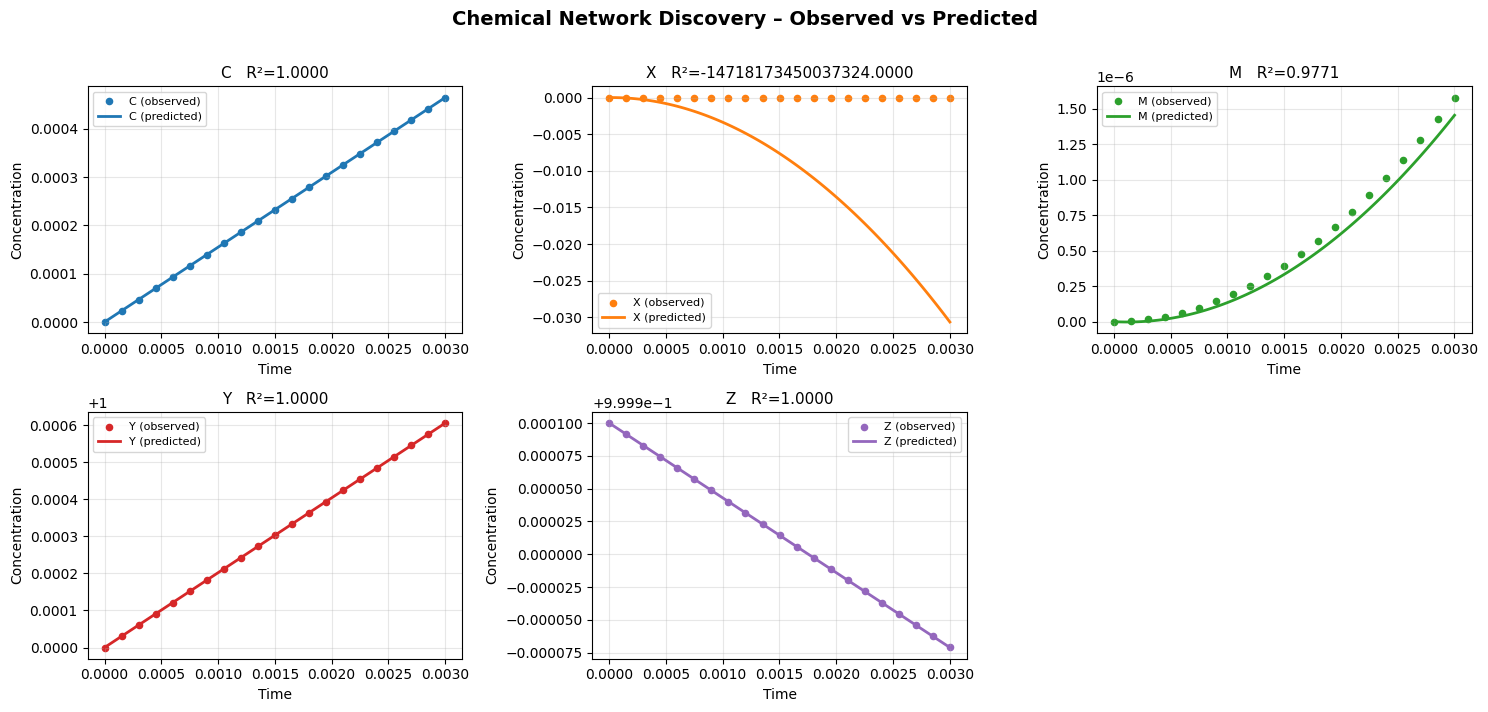

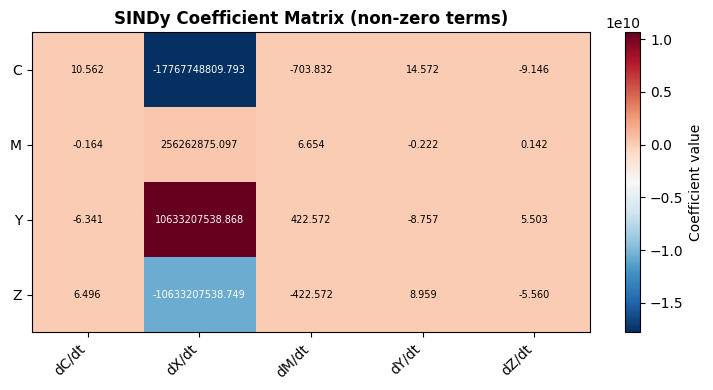

In [8]:
sd = DiscoverNetwork(timecourse.timecourse_df, poly_degree=1, threshold=0.1)

In [10]:
sd.model.equations()

[' 10.562 C + -0.001 M + -8.264 Y +  2.388 Z',
 ' 0.000',
 '-200372.943 C +  6.654 M +  156777.016 Y + -44233.092 Z',
 ' 11.182 C + -0.001 M + -8.757 Y +  2.528 Z',
 '-24.874 C +  0.001 M +  19.506 Y + -5.560 Z']

In [11]:
sd.summary()

,dC/dt,dX/dt,dM/dt,dY/dt,dZ/dt
C,10.562274,-1.776775e+10,-703.831505,14.572333,-9.145953
M,-0.163597,2.562629e+08,6.653887,-0.222361,0.141698
Y,-6.340935,1.063321e+10,422.571981,-8.756800,5.503369
Z,6.495936,-1.063321e+10,-422.572022,8.958801,-5.560369



  Discovered Chemical Rate Equations
(C)' =  0.000
(X)' =  0.000
(M)' = -0.031 C M +  0.011 C Z +  0.035 M^2 + -0.037 M Y +  0.010 M Z +  0.007 Y^2 +  0.012 Y Z + -0.004 Z^2
(Y)' =  0.000
(Z)' =  0.000

R² on time derivatives per species:
  C: -1099500.371302
  X: 0.437233
  M: 0.997573
  Y: -366542.995961
  Z: -35047511.834530

R² on simulated trajectories per species:
  C: 0.973062
  X: -37086601889363591168.000000
  M: 0.889480
  Y: 0.988308
  Z: -2.941739



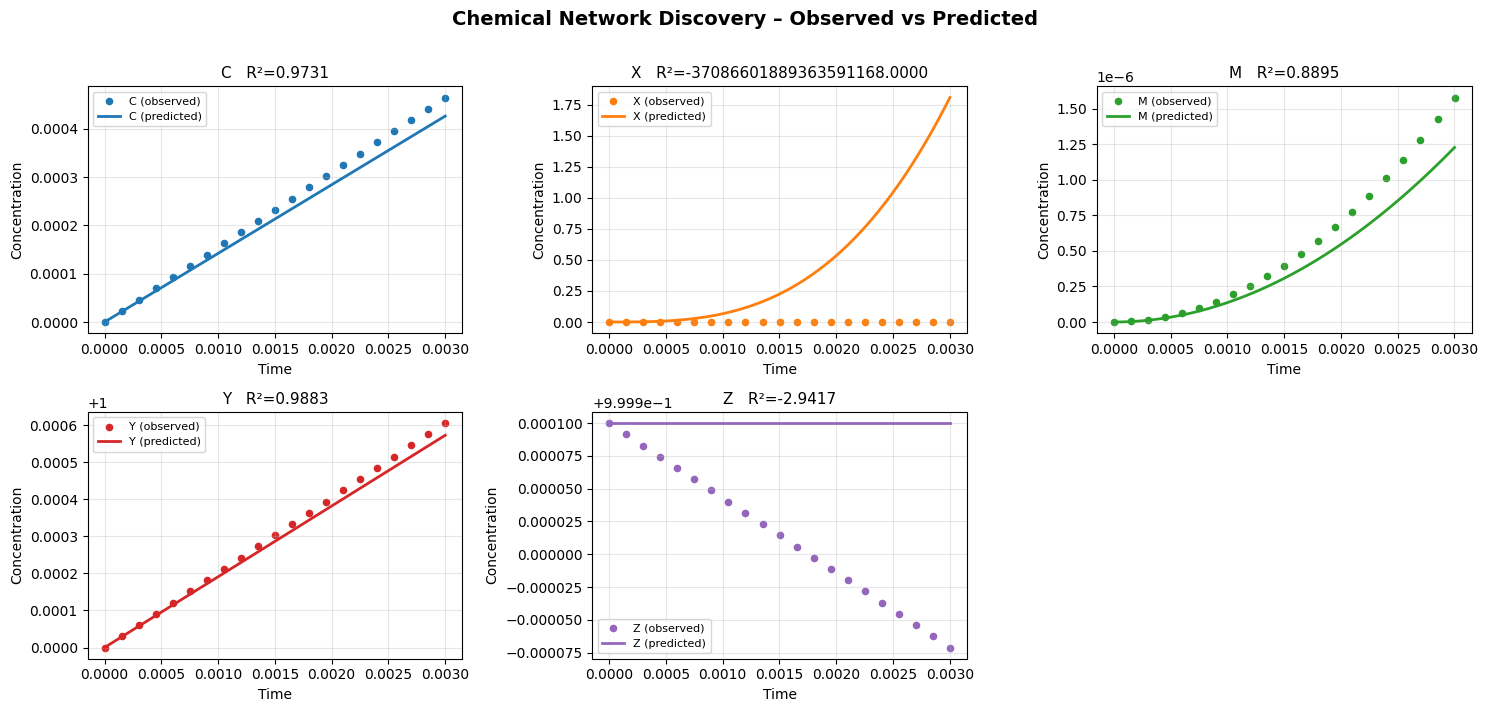

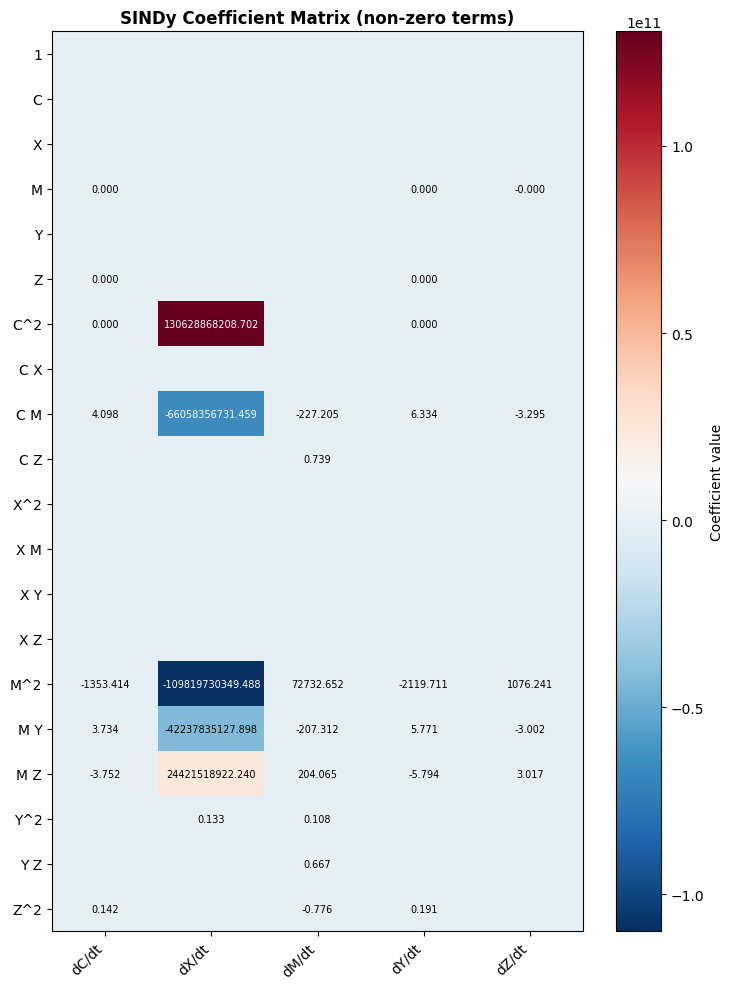

In [12]:
sd = DiscoverNetwork(timecourse.timecourse_df, poly_degree=2, threshold=0.1)

# Analysis of fits

# Species